## GPU Setup

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.set_visible_devices(gpus[0], 'GPU')
    tf.config.experimental.set_memory_growth(gpus[0], True)

print("Available Devices:", tf.config.list_physical_devices())

Available Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Importing Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

from tqdm import tqdm
from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalMaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
import sys
import numpy
print("Python path:", sys.executable)
print("NumPy version:", numpy.__version__)

Python path: d:\Code\4th SEM\AI Training\f\venv\Scripts\python.exe
NumPy version: 1.23.5


## Exploratory Data Analysis (EDA)

In [ ]:
df = pd.read_csv(r"D:\Code\4th SEM\AI Training\Datasets\fashion_recommendation\myntradataset\styles.csv", on_bad_lines="skip")
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:
df.shape

(44424, 10)

In [ ]:
df.isnull().sum()

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

In [ ]:
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44077 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44077 non-null  int64  
 1   gender              44077 non-null  object 
 2   masterCategory      44077 non-null  object 
 3   subCategory         44077 non-null  object 
 4   articleType         44077 non-null  object 
 5   baseColour          44077 non-null  object 
 6   season              44077 non-null  object 
 7   year                44077 non-null  float64
 8   usage               44077 non-null  object 
 9   productDisplayName  44077 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.7+ MB


## Category Distribution

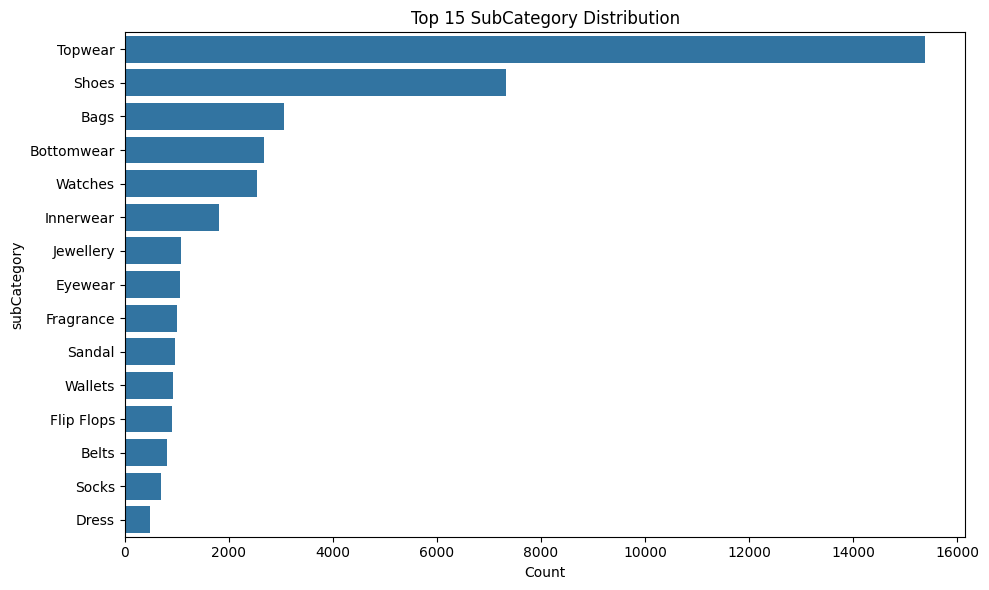

In [ ]:
top_15 = df['subCategory'].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_15.values, y=top_15.index)
plt.title("Top 15 SubCategory Distribution")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## Gender Distribution

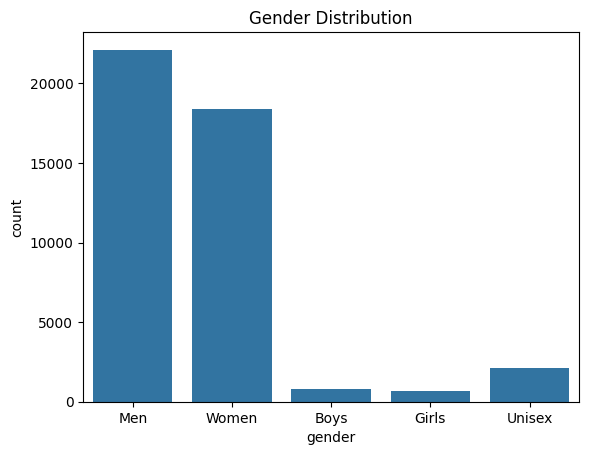

In [ ]:
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show()

## Usage Distribution

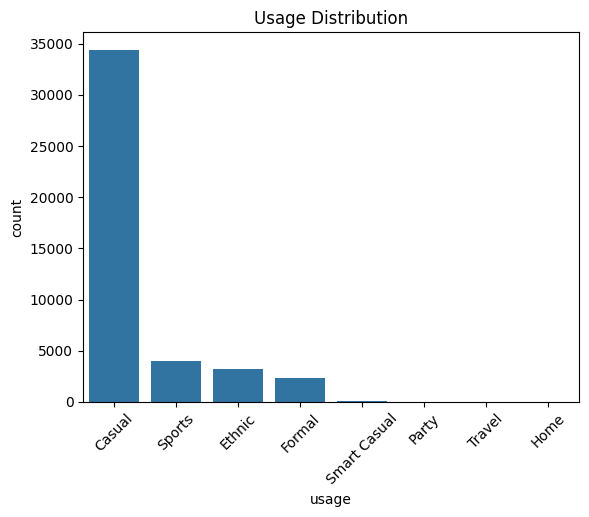

In [ ]:
sns.countplot(
    data=df,
    x='usage',
    order=df['usage'].value_counts().index
)
plt.title("Usage Distribution")
plt.xticks(rotation=45)
plt.show()

## Year-wise Product Count Trend

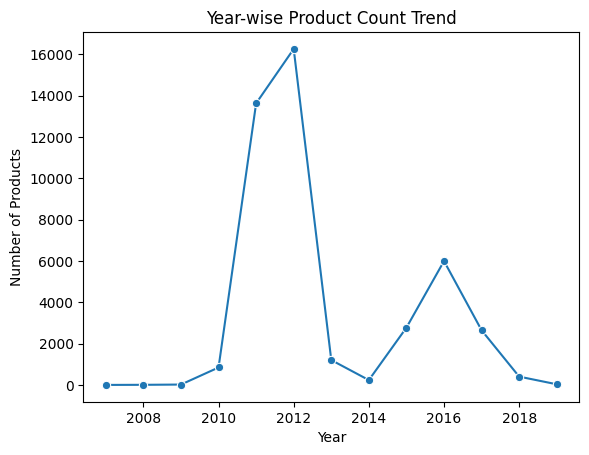

In [ ]:
year_counts = df['year'].value_counts().sort_index()

sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title("Year-wise Product Count Trend")
plt.xlabel("Year")
plt.ylabel("Number of Products")
plt.show()

## Season vs Usage Relationship Heatmap

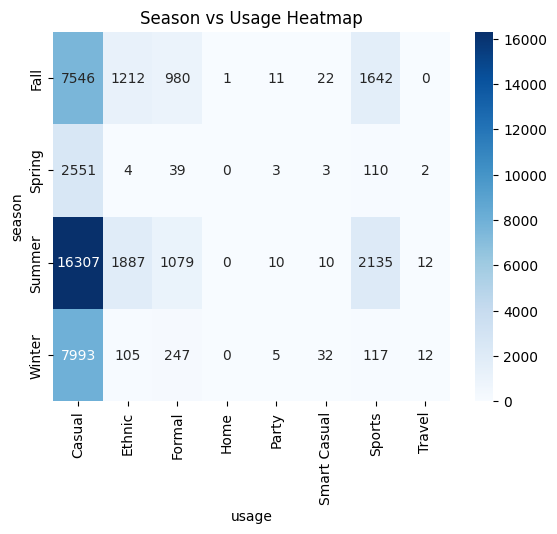

In [ ]:
heatmap_data = pd.crosstab(df['season'], df['usage'])

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues')
plt.title("Season vs Usage Heatmap")
plt.show()

## Gender VS Master Category

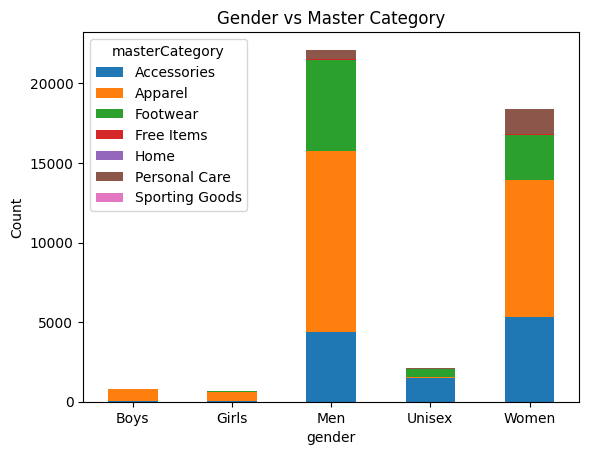

In [ ]:
cross_tab = pd.crosstab(df['gender'], df['masterCategory'])

cross_tab.plot(kind='bar', stacked=True)
plt.title("Gender vs Master Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Sample Image Visualization

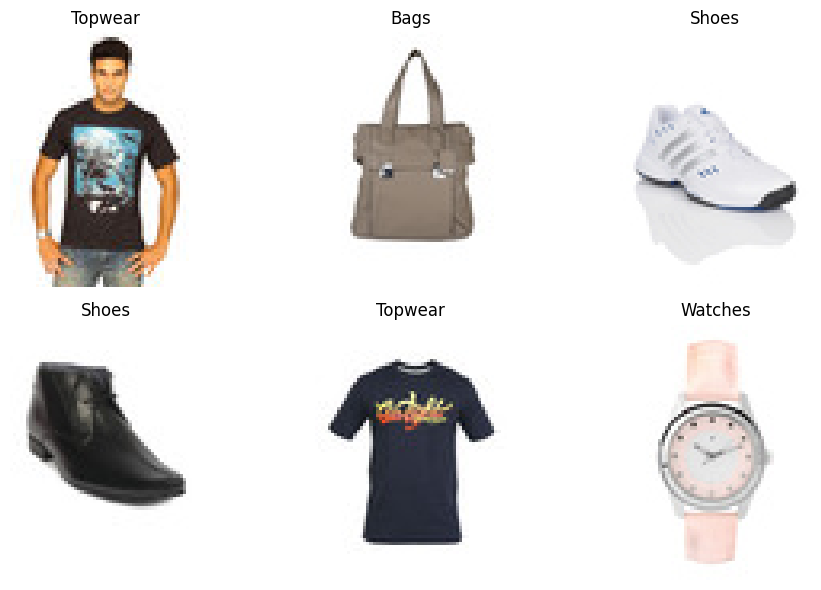

In [ ]:
images_folder = r"D:\Code\4th SEM\AI Training\Datasets\fashion_recommendation\myntradataset\images"

sample_df = df.sample(6)

plt.figure(figsize=(10,6))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = os.path.join(images_folder, str(row['id']) + ".jpg")
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(row['subCategory'])
        plt.axis("off")

plt.tight_layout()
plt.show()

## Model Comparisons

## Define Features & Target

In [ ]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop("subCategory", axis=1)
y = df_encoded["subCategory"]

In [ ]:
df_encoded

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,2,1,38,103,25,0,2011.0,0,27468
1,39386,2,1,6,56,2,2,2012.0,0,20484
2,59263,4,0,42,139,37,3,2016.0,0,27233
3,21379,2,1,6,127,1,0,2011.0,0,16219
4,53759,2,1,38,133,13,2,2012.0,0,21985
...,...,...,...,...,...,...,...,...,...,...
44419,17036,2,2,30,19,44,2,2013.0,0,11086
44420,6461,2,2,11,39,33,2,2011.0,0,15791
44421,18842,2,1,38,133,2,0,2011.0,0,21959
44422,46694,4,5,12,91,2,1,2017.0,0,23735


## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
# Required imports
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42)
    )
}

results = []

# Train & Evaluate
for name, clf in models.items():
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, predictions, average='weighted', zero_division=0),
        "F1": f1_score(y_test, predictions, average='weighted', zero_division=0)
    })

# Create DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0        Decision Tree  0.994782   0.994811  0.994782  0.994574
1        Random Forest  0.993421   0.992740  0.993421  0.992960
2                  KNN  0.881352   0.877755  0.881352  0.878448
3  Logistic Regression  0.827700   0.781464  0.827700  0.791679


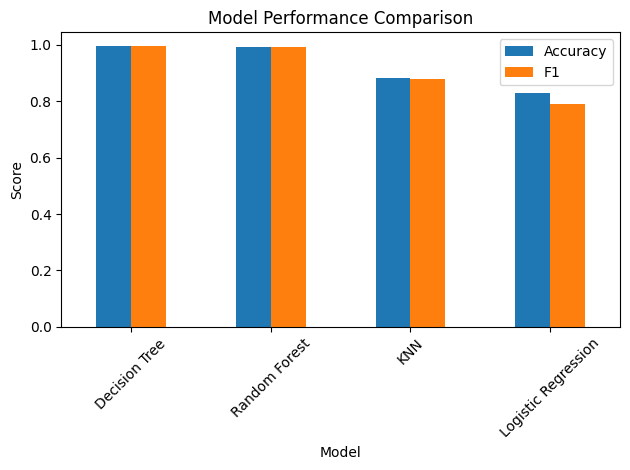

In [ ]:
results_df.set_index("Model")[["Accuracy", "F1"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Random Forest

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9930807622504537


## Confusion Matrix

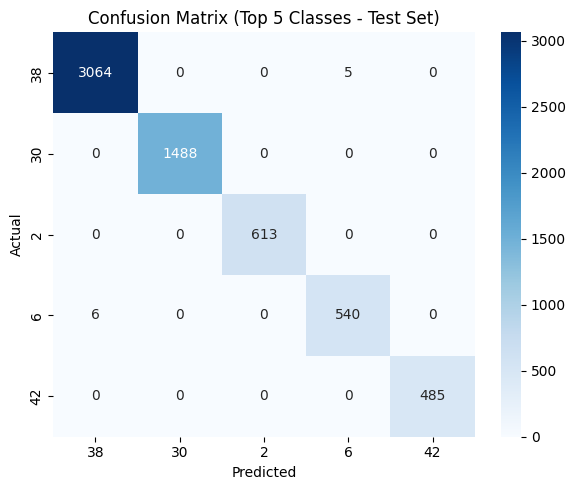

In [ ]:
# Get top 5 most frequent classes in test set
top_classes = pd.Series(y_test).value_counts().head(5).index

# Filter test & predictions for those classes
mask = np.isin(y_test, top_classes)

y_test_top = y_test[mask]
rf_pred_top = rf_pred[mask]

# Compute confusion matrix
cm_small = confusion_matrix(y_test_top, rf_pred_top, labels=top_classes)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_small,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=top_classes,
    yticklabels=top_classes
)

plt.title("Confusion Matrix (Top 5 Classes - Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Classification Report

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        26
           1       1.00      0.96      0.98        26
           2       0.99      0.99      0.99       618
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00       159
           6       0.98      0.99      0.99       546
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        86
           9       1.00      0.14      0.25         7
          10       1.00      1.00      1.00       210
          11       0.99      0.99      0.99       180
          12       0.99      1.00      0.99       214
          13       1.00      1.00      1.00        17
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         5
          16       1.00      0.97      0.98        59
          18       1.00    

d:\Code\4th SEM\AI Training\f\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code\4th SEM\AI Training\f\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code\4th SEM\AI Training\f\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Cod

## Load Feature Extraction Model

In [ ]:
feature_model = Sequential([
    ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    GlobalMaxPooling2D()
])

feature_model.trainable = False
print("Feature model ready.")

Feature model ready.


## Helper Functions

In [ ]:
def load_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((224,224))
    return np.array(img)

def extract_batch(batch_images):
    batch_images = preprocess_input(batch_images)
    features = feature_model.predict(batch_images, verbose=0)
    features = features / np.linalg.norm(features, axis=1, keepdims=True)
    return features

## Build Feature Index (RUN ONCE)

In [ ]:
# dataset_path = "dataset"

# image_paths = []
# categories = []

# for category in os.listdir(dataset_path):
#     category_path = os.path.join(dataset_path, category)
#     if os.path.isdir(category_path):
#         for file in os.listdir(category_path):
#             image_paths.append(os.path.join(category_path, file))
#             categories.append(category)

# print("Total images:", len(image_paths))

# batch_size = 32
# all_features = []

# for i in tqdm(range(0, len(image_paths), batch_size)):
#     batch_paths = image_paths[i:i+batch_size]
#     batch_images = np.array([load_image(p) for p in batch_paths])
#     batch_features = extract_batch(batch_images)
#     all_features.append(batch_features)

# features = np.vstack(all_features)

# np.save("features.npy", features)
# pickle.dump(image_paths, open("filenames.pkl", "wb"))
# pickle.dump(categories, open("categories.pkl", "wb"))

# knn = NearestNeighbors(n_neighbors=6, metric="cosine")
# knn.fit(features)

# pickle.dump(knn, open("knn_model.pkl", "wb"))

# print("Index built successfully.")

Total images: 15190


100%|██████████| 475/475 [08:32<00:00,  1.08s/it]


Index built successfully.


## Load Saved Index (Future Sessions)

In [ ]:
features = np.load("features.npy")
image_paths = pickle.load(open("filenames.pkl", "rb"))
categories = pickle.load(open("categories.pkl", "rb"))
knn = pickle.load(open("knn_model.pkl", "rb"))

print("Index loaded.")

Index loaded.


## Recommendation Function

In [ ]:
def recommend(image_path):
    img = load_image(image_path)
    img_display = Image.open(image_path)

    query = np.expand_dims(img, axis=0)
    query = preprocess_input(query)
    query_features = feature_model.predict(query, verbose=0)
    query_features = query_features[0] / np.linalg.norm(query_features)

    distances, indices = knn.kneighbors([query_features])

    plt.figure(figsize=(15,5))
    plt.subplot(1,6,1)
    plt.imshow(img_display)
    plt.title("Query")
    plt.axis("off")

    for i in range(1,6):
        idx = indices[0][i]
        similarity = (1 - distances[0][i]) * 100

        plt.subplot(1,6,i+1)
        plt.imshow(Image.open(image_paths[idx]))
        plt.title(f"{similarity:.1f}%")
        plt.axis("off")

    plt.show()

## Test Recommendation

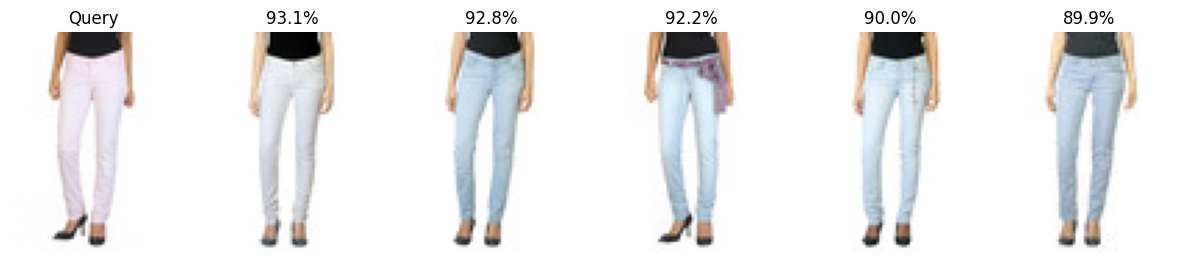

In [ ]:
recommend(image_paths[1987])

## EVALUATION SECTION

## Category Distribution Graph

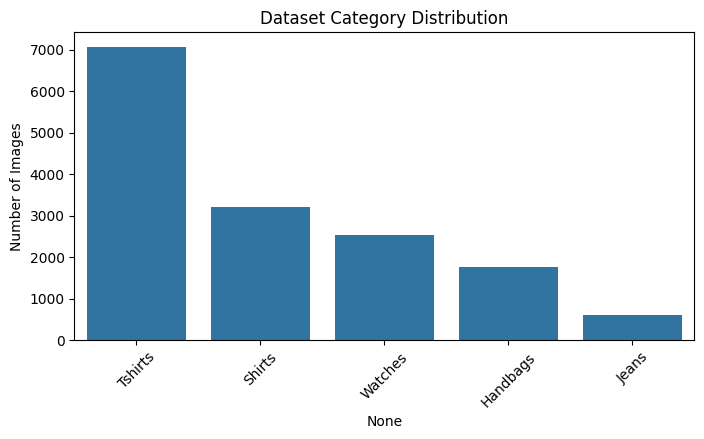

In [ ]:
category_counts = pd.Series(categories).value_counts()

plt.figure(figsize=(8,4))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.xticks(rotation=45)
plt.title("Dataset Category Distribution")
plt.ylabel("Number of Images")
plt.show()

## Precision@5

In [ ]:
def precision_at_k(k=5, samples=100):
    correct = 0
    total = 0
    
    for i in range(samples):
        distances, indices = knn.kneighbors([features[i]])
        query_category = categories[i]
        
        for idx in indices[0][1:k+1]:
            if categories[idx] == query_category:
                correct += 1
            total += 1
            
    return correct / total

print("Precision@5:", precision_at_k(5))

Precision@5: 0.988


## PCA Variance Graph

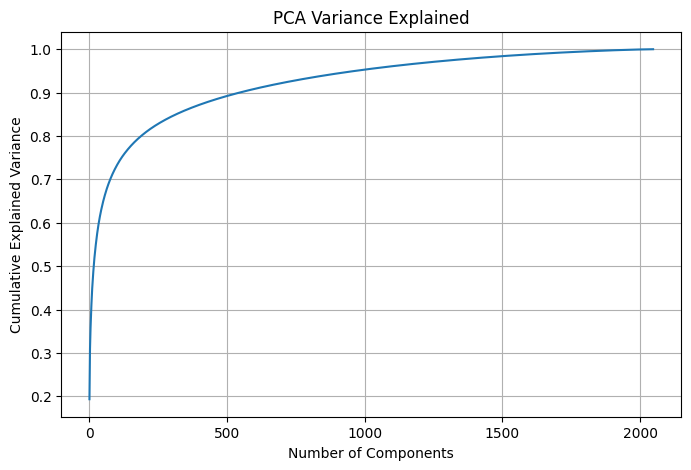

Components for 95% variance: 965


In [ ]:
pca = PCA()
pca.fit(features)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")
plt.grid()
plt.show()

print("Components for 95% variance:",
      np.argmax(cumulative_variance >= 0.95))